# Project 8 main report: Tiny NeRF vs Extended NeRF (Task 3)
**Group 4**: Karan Rooprai (n12498122), Nhu Hieu Nguyen (n12194778)

Reproduces every number and figure in the report from the saved weights. **No training happens
here**: the four models are loaded from `tinynerf.pth`, `extended_nerf.pth`,
`ablation_no_viewdirs.pth` and `ablation_uniform96.pth`, and the training curves from
`training_history.json`. Every metric is computed on the 6 held-out test views (100-105), which no
model saw during training. Rendering at test time has no random jitter, so the numbers repeat
exactly from run to run; only the render times depend on the machine.

| Section | Question |
|---|---|
| 1 | How good is each model on the held-out views, overall and view by view? |
| 2 | What do the differences look like? |
| 3 | Did every model get the same training, and had it converged? |
| 4 | Does the scene really look different from different directions, and which model follows that? |
| 5 | Where do the samples land, and when does hierarchical sampling pay? |
| 6 | Novel views: a 360-degree turntable of generated camera poses (the "3D movie") |
| 7 | Every number the report quotes |

In [1]:
# Libraries (the Tutorial 10.4 stack). This notebook only evaluates the saved models.
import json
import time
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

# Set device. Every tensor and network below is moved to it with .to(device).
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none"
print(f"Using device: {device} | GPU: {gpu_name} | torch {torch.__version__}")
# Recent NVIDIA GPUs run convolutions in TF32 (a 10-bit mantissa) by default, which moves SSIM's
# Gaussian filtering in the third decimal; full float32 makes GPU and CPU runs agree.
torch.backends.cudnn.allow_tf32 = False

# Test-time rendering has no randomness; the seed only pins anything left random.
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

# Scene bounds and sample budgets shared by every model in this project.
NEAR, FAR = 2.0, 6.0          # ray segment that contains the object (tutorial values)
N_SAMPLES_TINY = 64           # Tiny NeRF: uniform samples per ray (tutorial value)
N_C, N_F = 32, 64             # Extended NeRF: coarse samples, extra fine samples (starter values)

# Report figures are drawn at their printed size, so 7 pt here is 7 pt on the page.
plt.rcParams.update({"font.size": 7, "axes.titlesize": 7, "axes.labelsize": 7,
                     "legend.fontsize": 6, "xtick.labelsize": 6, "ytick.labelsize": 6,
                     "pdf.fonttype": 42})
TEXT_WIDTH, COLUMN_WIDTH = 7.0, 3.4      # inches: the report's page width and column width

Using device: cuda | GPU: NVIDIA A16-4Q | torch 2.13.0+cu126


## Data, rays and models
The definitions below are copied from `TinyNeRF.ipynb` and `ExtendedNeRF.ipynb` without change, so
that this notebook rebuilds exactly the models that were trained.

Load the 106 posed views and split them as the starter code does: 0-99 for training, 100-105 held out.

In [2]:
data = np.load('tiny_nerf_data.npz')
images = torch.from_numpy(data['images']).float().to(device)
poses = torch.from_numpy(data['poses']).float().to(device)
focal = float(data['focal'])
H, W = images.shape[1:3]
K = torch.Tensor([[focal, 0, W/2.0], [0, focal, H/2.0], [0, 0, 1]]).float().to(device)
print(f"dataset: Images shape={images.shape}, Poses shape={poses.shape}, Intrinsics={K.shape}")

# Splitting the dataset into training and test sets exactly as the starter code does:
# the last 6 views are never seen during training and are used for every reported metric.
test_images, test_poses = images[100:], poses[100:]
train_images, train_poses = images[:100], poses[:100]
print(f"training split: {train_images.shape}, training pose shape: {train_poses.shape}")
print(f"test split: {test_images.shape}, test pose shape: {test_poses.shape}")

dataset: Images shape=torch.Size([106, 100, 100, 3]), Poses shape=torch.Size([106, 4, 4]), Intrinsics=torch.Size([3, 3])
training split: torch.Size([100, 100, 100, 3]), training pose shape: torch.Size([100, 4, 4])
test split: torch.Size([6, 100, 100, 3]), test pose shape: torch.Size([6, 4, 4])


`get_rays`: the origin and direction of the ray through every pixel of a camera.

In [3]:
def get_rays(K, c2w, H, W):
    """
    Get the origin and direction of the ray through every pixel of a camera with
    intrinsics K and camera-to-world pose c2w (Tutorial 10.4, unchanged).
    """
    # 1. Create pixel grid, x first
    i, j = torch.meshgrid(
        torch.arange(W, dtype=torch.float32, device=c2w.device),
        torch.arange(H, dtype=torch.float32, device=c2w.device),
        indexing='xy'
    )

    # 2. Get directions in camera coordinates: (u - cx)/fx, (v - cy)/fy, with the camera
    #    looking down -z and the y-axis flipped (standard NeRF orientation)
    dirs = torch.stack([
        (i - K[0, 2]) / K[0, 0],
        -(j - K[1, 2]) / K[1, 1],
        -torch.ones_like(i)
    ], dim=-1)

    # 3. Transform directions to world space: (H, W, 3) @ (3, 3) -> (H, W, 3)
    rays_d = dirs @ c2w[:3, :3].T

    # 4. Origin is the translation vector of the camera-to-world matrix
    rays_o = c2w[:3, -1].expand(rays_d.shape)
    return rays_o, rays_d

Positional encoding $\gamma$, which lets a small MLP represent fine detail.

In [4]:
class PositionalEncoding(torch.nn.Module):
    """
    Positional encoding gamma(p) = [p, sin(2^k pi p), cos(2^k pi p)], k = 0..L-1 (Tutorial 10.4).
    Maps (N, D) -> (N, D + 2*L*D).
    """
    def __init__(self, L_embed=6):
        super(PositionalEncoding, self).__init__()
        self.L_embed = L_embed
        self.bands = (2.0 ** torch.arange(L_embed, dtype=torch.float32).to(device)) * torch.pi
        self.bands = self.bands.view(1, L_embed, 1)  # shape (1, L_embed, 1)

    def forward(self, x):
        x_scaled = x.unsqueeze(-2) * self.bands                                  # (N, L, D)
        sin_cos = torch.cat([torch.sin(x_scaled), torch.cos(x_scaled)], dim=-2)  # (N, 2L, D)
        sin_cos = sin_cos.flatten(start_dim=-2)                                  # (N, 2LD)
        return torch.cat([x, sin_cos], dim=-1)                                   # (N, D + 2LD)

The Tutorial 10.4 model (Tiny NeRF): position in, density and one colour out.

In [5]:
class TinyNeRF(torch.nn.Module):
    """
    The Tutorial 10.4 model, unchanged apart from its name: a 3-layer MLP that maps the encoded
    position gamma(x) to (sigma, rgb). It never sees the viewing direction, so it is a matte
    renderer: every 3D point has one colour whichever camera looks at it.
    """
    def __init__(self, filter_size=128, L_embed=6):
        super(TinyNeRF, self).__init__()
        self.positional_encoding = PositionalEncoding(L_embed)
        self.layer1 = torch.nn.Linear(3 + 3*2*L_embed, filter_size)
        self.layer2 = torch.nn.Linear(filter_size, filter_size)
        self.layer3 = torch.nn.Linear(filter_size, 4)
        self.relu = torch.nn.functional.relu

    def forward(self, x):
        x = self.positional_encoding(x)
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        sigma = self.relu(x[..., [0]])     # density >= 0
        rgb = torch.sigmoid(x[..., 1:])    # colour in [0, 1]
        return torch.cat([sigma, rgb], dim=-1)

Task 1's model: density from position only, colour from position features and the viewing direction.

In [6]:
class NeRF(torch.nn.Module):
    r"""
    TASK 1. NeRF MLP with view-direction dependency (layers exactly as in the starter code).
    Density depends on position only; colour depends on position features + view direction.

        gamma(x) -> layer1 -> layer2 -> h --> sigma_layer --> sigma        (geometry)
                                          \-> feature_layer --+
                                gamma(d) ---------------------+-> color_layer1 -> color_layer2 -> rgb

    Because sigma is computed before the direction enters, the geometry is the same from every
    camera (multi-view consistency); only the colour can change with the angle, which is what
    lets the model reproduce specular highlights and reflections.

    view_dependent=False is used only by the ablation study: the direction input is replaced by
    zeros, so the network keeps exactly the same size but becomes a matte renderer again.
    """
    def __init__(self, filter_size=128, L_embed=6, L_dir=4, view_dependent=True):
        super(NeRF, self).__init__()
        self.view_dependent = view_dependent
        self.positional_encoding = PositionalEncoding(L_embed)
        self.direction_encoding = PositionalEncoding(L_dir)

        x_dim = 3 + 3 * 2 * L_embed   # 39 for L_embed = 6
        d_dim = 3 + 3 * 2 * L_dir     # 27 for L_dir = 4

        # Position trunk
        self.layer1 = torch.nn.Linear(x_dim, filter_size)
        self.layer2 = torch.nn.Linear(filter_size, filter_size)

        # Density
        self.sigma_layer = torch.nn.Linear(filter_size, 1)
        # geometric features passed on to the colour head
        self.feature_layer = torch.nn.Linear(filter_size, filter_size)

        # Color head conditioned on view direction
        self.color_layer1 = torch.nn.Linear(filter_size + d_dim, filter_size // 2)
        self.color_layer2 = torch.nn.Linear(filter_size // 2, 3)

    def forward(self, x, dir):
        # Position trunk on the encoded 3D point
        h = F.relu(self.layer1(self.positional_encoding(x)))
        h = F.relu(self.layer2(h))

        # Density from position only (ReLU keeps it non-negative)
        sigma = F.relu(self.sigma_layer(h))

        # Colour from the geometric features and the encoded unit viewing direction.
        # As in the original NeRF, the feature vector has no activation before the concat.
        if not self.view_dependent:
            dir = torch.zeros_like(dir)
        features = self.feature_layer(h)
        c = F.relu(self.color_layer1(torch.cat([features, self.direction_encoding(dir)], dim=-1)))
        rgb = torch.sigmoid(self.color_layer2(c))
        return torch.cat([sigma, rgb], dim=-1)

Volume rendering: the pixel colour is the weighted sum of the samples' colours, with weights $w_i = T_i\alpha_i$.

In [7]:
def volume_rendering(sigma, rgb, t_vals):
    """
    Discrete volume rendering (Tutorial 10.4, unchanged).
    sigma: [N_rays, N_samples], rgb: [N_rays, N_samples, 3], t_vals: [N_rays, N_samples].
    Returns the pixel colours [N_rays, 3] and the per-sample weights w_i = T_i * alpha_i.
    """
    # Distance between adjacent samples, with a very large last interval
    deltas = t_vals[..., 1:] - t_vals[..., :-1]
    last_dist = torch.full_like(deltas[..., :1], 1e10)
    deltas = torch.cat([deltas, last_dist], dim=-1)

    # alpha_i = 1 - exp(-sigma_i * delta_i)  (sigma >= 0 is ensured by the ReLU in the MLP)
    alpha = 1.0 - torch.exp(-sigma * deltas)

    # Transmittance T_i = prod_{j<i} (1 - alpha_j), with T_1 = 1
    shifted_transmittance = torch.cat([torch.ones_like(alpha[..., :1]), 1.0 - alpha + 1e-10], dim=-1)
    T = torch.cumprod(shifted_transmittance, dim=-1)[..., :-1]

    # colour blending
    weights = alpha * T
    rgb_map = torch.sum(weights[..., None] * rgb, dim=-2)
    return rgb_map, weights

Tiny NeRF's renderer: 64 evenly spaced samples, one network.

In [8]:
def render_rays_tiny(network, rays_o, rays_d, near, far, num_samples, rand=False):
    """Tutorial 10.4 renderer: uniform (stratified when rand=True) samples, one network."""
    # 1. Generate t_vals for each ray: [N_rays, num_samples]
    z_vals = torch.linspace(near, far, num_samples, device=rays_o.device)
    z_vals = z_vals.expand(list(rays_o.shape[:-1]) + [num_samples])
    if rand:
        # 1.1 Add jitter: one uniform sample inside each of the num_samples bins
        bin_edges = torch.linspace(near, far, num_samples + 1, device=rays_o.device)
        lower = bin_edges[:-1]; widths = bin_edges[1:] - lower
        z_vals = lower + torch.rand_like(z_vals) * widths

    # 2. Points in space: r(t) = o + td
    pts = rays_o[..., None, :] + z_vals[..., :, None] * rays_d[..., None, :]

    # 3. network pass to compute density and colour
    raw = network(pts.view(-1, 3)).view(list(pts.shape[:-1]) + [4])   # [N_rays, N_samples, 4]
    sigma, rgb = raw[..., 0], raw[..., 1:]

    # 4. Volume rendering
    rgb_map, weights = volume_rendering(sigma, rgb, z_vals)
    return rgb_map

`sample_pdf`, provided by the starter code: inverse-transform sampling from the coarse weights.

In [9]:
def sample_pdf(bins, weights, N_samples, rand=False):
    """Inverse-transform sampling along each ray (provided by the starter code, unchanged)."""
    # Get PDF and CDF from weights
    weights = weights + 1e-5  # Prevent division by zero
    pdf = weights / torch.sum(weights, dim=-1, keepdim=True)
    cdf = torch.cumsum(pdf, dim=-1)
    cdf = torch.cat([torch.zeros_like(cdf[..., :1]), cdf], dim=-1)  # [N_rays, N_bins + 1]

    # Sample uniform points u
    if rand:
        u = torch.rand(list(cdf.shape[:-1]) + [N_samples], device=cdf.device)
    else:
        u = torch.linspace(0., 1., steps=N_samples, device=cdf.device)
        u = u.expand(list(cdf.shape[:-1]) + [N_samples])
    u = u.contiguous()

    # Find indices where u fits in the CDF
    inds = torch.searchsorted(cdf, u, right=True)
    below = torch.max(torch.zeros_like(inds - 1), inds - 1)
    above = torch.min((cdf.shape[-1] - 1) * torch.ones_like(inds), inds)

    # Gather CDF values for the intervals
    cdf_g0 = torch.gather(cdf, -1, below)
    cdf_g1 = torch.gather(cdf, -1, above)
    bins_g0 = torch.gather(bins, -1, below)
    bins_g1 = torch.gather(bins, -1, above)

    # Linear interpolation
    denom = (cdf_g1 - cdf_g0)
    denom = torch.where(denom < 1e-5, torch.ones_like(denom), denom)
    t = (u - cdf_g0) / denom
    samples = bins_g0 + t * (bins_g1 - bins_g0)
    return samples  # [N_rays, N_samples]

Task 2's renderer (coarse pass, `sample_pdf`, fine pass) and the uniform renderer of ablation B.

In [10]:
def stratified_t_vals(rays_o, near, far, n_samples, rand=False):
    """Evenly spaced depths along every ray, jittered inside their bins when rand=True
    (the tutorial's sampling, factored out so the coarse pass and the ablation share it)."""
    t_vals = torch.linspace(near, far, n_samples, device=rays_o.device)
    t_vals = t_vals.expand(list(rays_o.shape[:-1]) + [n_samples])
    if rand:
        bin_edges = torch.linspace(near, far, n_samples + 1, device=rays_o.device)
        lower, widths = bin_edges[:-1], bin_edges[1:] - bin_edges[:-1]
        t_vals = lower + torch.rand_like(t_vals) * widths
    return t_vals


def query_and_render(network, rays_o, rays_d, t_vals):
    """
    Evaluate a view-dependent NeRF at the points r(t) = o + t d and volume-render them.
    The viewing direction is the unit ray direction, shared by every sample on the ray.
    Returns the pixel colours [N_rays, 3] and the weights [N_rays, N_samples].
    """
    pts = rays_o[..., None, :] + t_vals[..., :, None] * rays_d[..., None, :]   # [N_rays, N, 3]
    viewdirs = F.normalize(rays_d, dim=-1)[..., None, :].expand(pts.shape)     # unit vectors
    raw = network(pts.reshape(-1, 3), viewdirs.reshape(-1, 3))
    raw = raw.view(list(pts.shape[:-1]) + [4])                                  # [N_rays, N, 4]
    return volume_rendering(raw[..., 0], raw[..., 1:], t_vals)


def render_rays(coarse_network, fine_network, rays_o, rays_d, near, far, N_c, N_f, rand=False,
                return_extras=False):
    """
    TASK 2. Hierarchical sampling with a coarse and a fine network.
    Returns the coarse and the fine pixel colours (both are supervised during training);
    the fine colour is the model's output. return_extras=True also returns the sample depths
    and weights of both passes, which main_report.ipynb uses to show where samples land.
    """
    # 1. Stratified Sampling (Coarse): N_c depths per ray, jittered during training
    t_coarse = stratified_t_vals(rays_o, near, far, N_c, rand)

    # Coarse pass: evaluate the coarse network and get the volume rendering weights,
    # which indicate where along each ray the geometry is likely to be
    rgb_map_c, weights_c = query_and_render(coarse_network, rays_o, rays_d, t_coarse)

    # 2. Hierarchical Sampling (Fine): treat the coarse weights as a piecewise-constant PDF
    # over the bins between consecutive coarse samples and draw N_f extra depths from it.
    # The two end weights are dropped so the PDF has one value per interior bin (as in the
    # original NeRF), and no gradient flows through the sampling.
    t_mid = 0.5 * (t_coarse[..., 1:] + t_coarse[..., :-1])                       # [N_rays, N_c-1]
    t_fine = sample_pdf(t_mid, weights_c[..., 1:-1], N_f, rand=rand).detach()   # [N_rays, N_f]

    # Combine and sort all samples, so the fine network sees N_c + N_f points per ray
    t_all, _ = torch.sort(torch.cat([t_coarse, t_fine], dim=-1), dim=-1)

    # Fine pass: evaluate the fine network at all points
    rgb_map_f, weights_f = query_and_render(fine_network, rays_o, rays_d, t_all)

    if return_extras:
        extras = {"t_coarse": t_coarse, "weights_coarse": weights_c,
                  "t_fine": t_fine, "t_all": t_all, "weights_fine": weights_f}
        return rgb_map_c, rgb_map_f, extras
    return rgb_map_c, rgb_map_f


def render_rays_uniform(network, rays_o, rays_d, near, far, num_samples, rand=False):
    """Ablation renderer: one view-dependent network, uniform samples only (no coarse pass)."""
    t_vals = stratified_t_vals(rays_o, near, far, num_samples, rand)
    rgb_map, _ = query_and_render(network, rays_o, rays_d, t_vals)
    return rgb_map

Metrics (PSNR, SSIM) and a chunked full-image renderer.

In [11]:
def psnr(pred, target):
    """Peak signal-to-noise ratio for images in [0, 1] (the tutorial's -10 log10 MSE)."""
    return (-10. * torch.log10(F.mse_loss(pred, target))).item()


def _gaussian_window(size=11, sigma=1.5):
    coords = torch.arange(size, dtype=torch.float32, device=device) - size // 2
    g = torch.exp(-coords ** 2 / (2 * sigma ** 2))
    g = g / g.sum()
    return (g[:, None] @ g[None, :])[None, None]          # [1, 1, size, size]


def ssim(pred, target, data_range=1.0):
    """
    Structural similarity (Wang et al., 2004) with the standard 11x11 Gaussian window
    (sigma 1.5), K1 = 0.01, K2 = 0.03, computed per colour channel and averaged.
    pred, target: [H, W, 3] in [0, 1].
    """
    x = pred.permute(2, 0, 1)[:, None]                     # [3, 1, H, W]
    y = target.permute(2, 0, 1)[:, None]
    window = _gaussian_window()
    pad = window.shape[-1] // 2
    mu_x = F.conv2d(x, window, padding=pad)
    mu_y = F.conv2d(y, window, padding=pad)
    var_x = F.conv2d(x * x, window, padding=pad) - mu_x ** 2
    var_y = F.conv2d(y * y, window, padding=pad) - mu_y ** 2
    cov_xy = F.conv2d(x * y, window, padding=pad) - mu_x * mu_y
    C1, C2 = (0.01 * data_range) ** 2, (0.03 * data_range) ** 2
    ssim_map = ((2 * mu_x * mu_y + C1) * (2 * cov_xy + C2)) / \
               ((mu_x ** 2 + mu_y ** 2 + C1) * (var_x + var_y + C2))
    return ssim_map.mean().item()


@torch.no_grad()
def render_image(render_fn, c2w, chunk=4096):
    """
    Render a full H x W image from pose c2w. render_fn(rays_o, rays_d) -> [N_rays, 3].
    Rays are processed in chunks so that 96 samples per ray fit in GPU memory; chunking
    does not change the result.
    """
    rays_o, rays_d = get_rays(K, c2w, H, W)
    rays_o, rays_d = rays_o.reshape(-1, 3), rays_d.reshape(-1, 3)
    rgb = [render_fn(rays_o[i:i + chunk], rays_d[i:i + chunk])
           for i in range(0, rays_o.shape[0], chunk)]
    return torch.cat(rgb, dim=0).reshape(H, W, 3)

Camera poses on a sphere around the object (from the tutorial), used for the turntable in section 6.

In [12]:
# Interactive novel-view synthesis (Tutorial 10.4). The camera sits on a sphere around the object;
# theta = azimuth, phi = elevation, radius = distance.
trans_t = lambda t: torch.tensor([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, t],
    [0, 0, 0, 1],
], dtype=torch.float32)

# Rotation about x-axis (phi)
rot_phi = lambda phi: torch.tensor([
    [1, 0, 0, 0],
    [0, torch.cos(phi), -torch.sin(phi), 0],
    [0, torch.sin(phi),  torch.cos(phi), 0],
    [0, 0, 0, 1],
], dtype=torch.float32)

# Rotation about y-axis (theta)
rot_theta = lambda th: torch.tensor([
    [torch.cos(th), 0, -torch.sin(th), 0],
    [0, 1, 0, 0],
    [torch.sin(th), 0,  torch.cos(th), 0],
    [0, 0, 0, 1],
], dtype=torch.float32)

def pose_spherical(theta, phi, radius):
    c2w = trans_t(radius)
    c2w = rot_phi(torch.tensor(phi / 180. * np.pi)) @ c2w
    c2w = rot_theta(torch.tensor(theta / 180. * np.pi)) @ c2w
    c2w = torch.tensor([
        [-1, 0, 0, 0],
        [ 0, 0, 1, 0],
        [ 0, 1, 0, 0],
        [ 0, 0, 0, 1],
    ], dtype=torch.float32) @ c2w
    return c2w.to(device)

## Load the trained models
Each checkpoint holds the weights saved at the last training epoch. The four renderers below are
deterministic: no jitter, and `sample_pdf` draws evenly spaced values of $u$.

In [13]:
# Load every trained model from its checkpoint. No training happens in this notebook.
def load(path):
    """Read a checkpoint onto the current device (tensors only)."""
    return torch.load(path, map_location=device, weights_only=True)   # tensors only, no pickled code

checkpoint = load("tinynerf.pth")
tiny = TinyNeRF(filter_size=128, L_embed=6).to(device)
tiny.load_state_dict(checkpoint["model"]); tiny.eval()

checkpoint = load("extended_nerf.pth")
ext_coarse, ext_fine = NeRF(128, 6).to(device), NeRF(128, 6).to(device)
ext_coarse.load_state_dict(checkpoint["coarse"]); ext_fine.load_state_dict(checkpoint["fine"])
ext_coarse.eval(); ext_fine.eval()

checkpoint = load("ablation_no_viewdirs.pth")
noview_coarse = NeRF(128, 6, view_dependent=False).to(device)
noview_fine = NeRF(128, 6, view_dependent=False).to(device)
noview_coarse.load_state_dict(checkpoint["coarse"]); noview_fine.load_state_dict(checkpoint["fine"])
noview_coarse.eval(); noview_fine.eval()

checkpoint = load("ablation_uniform96.pth")
uniform_net = NeRF(128, 6).to(device)
uniform_net.load_state_dict(checkpoint["model"]); uniform_net.eval()

# One deterministic renderer per model: rays -> final colour
RENDERERS = {
    "Tiny NeRF": lambda o, d: render_rays_tiny(tiny, o, d, NEAR, FAR, N_SAMPLES_TINY),
    "Extended NeRF": lambda o, d: render_rays(ext_coarse, ext_fine, o, d, NEAR, FAR, N_C, N_F)[1],
    "No view dirs (abl. A)": lambda o, d: render_rays(noview_coarse, noview_fine, o, d, NEAR, FAR, N_C, N_F)[1],
    "Uniform 96 (abl. B)": lambda o, d: render_rays_uniform(uniform_net, o, d, NEAR, FAR, N_C + N_F),
}
# Coarse-network output of the two hierarchical models (to show what the fine pass adds)
COARSE_RENDERERS = {
    "Extended NeRF": lambda o, d: render_rays(ext_coarse, ext_fine, o, d, NEAR, FAR, N_C, N_F)[0],
    "No view dirs (abl. A)": lambda o, d: render_rays(noview_coarse, noview_fine, o, d, NEAR, FAR, N_C, N_F)[0],
}
PARAMS = {"Tiny NeRF": sum(p.numel() for p in tiny.parameters()),
          "Extended NeRF": sum(p.numel() for net in (ext_coarse, ext_fine) for p in net.parameters()),
          "No view dirs (abl. A)": sum(p.numel() for net in (noview_coarse, noview_fine) for p in net.parameters()),
          "Uniform 96 (abl. B)": sum(p.numel() for p in uniform_net.parameters())}
MODEL_NAMES = list(RENDERERS)
print("loaded:", ", ".join(f"{name} ({count:,} params)" for name, count in PARAMS.items()))

loaded: Tiny NeRF (22,148 params), Extended NeRF (96,904 params), No view dirs (abl. A) (96,904 params), Uniform 96 (abl. B) (48,452 params)


## 1. Quantitative comparison on held-out views
PSNR and SSIM per test view, mean render time per 100 x 100 image and parameter count. The coarse
network's own PSNR shows what the fine pass adds on top of it. Ablation A is the Extended model
with its direction input set to zero (hierarchical, matte); ablation B is one view-dependent
network on 96 uniform samples (view-dependent, no hierarchy).

In [14]:
# Quantitative evaluation on the 6 held-out test views: PSNR, SSIM and render time per image.
def timed_render(render_fn, c2w):
    """Render one view and return the image with its wall-clock time in seconds."""
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = time.time()
    img = render_image(render_fn, c2w)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return img, time.time() - start

render_image(RENDERERS["Tiny NeRF"], test_poses[0])   # warm-up so the first timing is fair

renders, results = {}, {}
for name, render_fn in RENDERERS.items():
    view_images, seconds = zip(*[timed_render(render_fn, test_poses[i]) for i in range(len(test_images))])
    renders[name] = [image.clamp(0, 1) for image in view_images]
    results[name] = {
        "psnr": [psnr(image, test_images[i]) for i, image in enumerate(renders[name])],
        "ssim": [ssim(image, test_images[i]) for i, image in enumerate(renders[name])],
        "render_seconds": float(np.mean(seconds)),
        "params": PARAMS[name],
    }
for name, render_fn in COARSE_RENDERERS.items():
    coarse = [render_image(render_fn, test_poses[i]).clamp(0, 1) for i in range(len(test_images))]
    results[name]["coarse_psnr"] = [psnr(image, test_images[i]) for i, image in enumerate(coarse)]

# Results table
header = f"{'model':24s}" + "".join(f"{'view ' + str(i):>8s}" for i in range(6)) + \
         f"{'mean PSNR':>11s}{'mean SSIM':>11s}{'s / image':>11s}{'params':>9s}"
print(header); print("-" * len(header))
for name in MODEL_NAMES:
    result = results[name]
    print(f"{name:24s}" + "".join(f"{view_psnr:8.2f}" for view_psnr in result["psnr"]) +
          f"{np.mean(result['psnr']):11.2f}{np.mean(result['ssim']):11.4f}{result['render_seconds']:11.3f}{result['params']:9,d}")
for name in COARSE_RENDERERS:
    print(f"  coarse network only, {name}: mean PSNR {np.mean(results[name]['coarse_psnr']):.2f} dB")
gain = np.mean(results['Extended NeRF']['psnr']) - np.mean(results['Tiny NeRF']['psnr'])
print(f"\nExtended NeRF - Tiny NeRF: {gain:+.2f} dB mean PSNR | "
      f"target 28 dB {'met' if np.mean(results['Extended NeRF']['psnr']) >= 28 else 'NOT met'}")

at_28 = int(np.sum(np.array(results["Extended NeRF"]["psnr"]) >= 28))
print(f"Extended NeRF views at or above 28 dB: {at_28} of {len(test_images)}")

model                     view 0  view 1  view 2  view 3  view 4  view 5  mean PSNR  mean SSIM  s / image   params
------------------------------------------------------------------------------------------------------------------
Tiny NeRF                  23.99   24.55   25.09   26.00   27.06   25.77      25.41     0.8940      0.033   22,148
Extended NeRF              26.42   27.57   28.76   29.18   29.40   29.29      28.44     0.9405      0.142   96,904
No view dirs (abl. A)      24.47   25.87   25.94   27.10   28.00   27.09      26.41     0.9165      0.137   96,904
Uniform 96 (abl. B)        26.01   27.41   28.42   29.26   29.56   29.37      28.34     0.9368      0.101   48,452
  coarse network only, Extended NeRF: mean PSNR 25.95 dB
  coarse network only, No view dirs (abl. A): mean PSNR 24.33 dB

Extended NeRF - Tiny NeRF: +3.03 dB mean PSNR | target 28 dB met
Extended NeRF views at or above 28 dB: 4 of 6


Every model renders the same six views, and some views are harder than others (thin parts seen
edge-on). Subtracting two models' PSNR view by view removes that shared difficulty, so a
difference that holds on every view is not an accident of which views were held out.

In [15]:
# Paired, view-by-view PSNR differences between models.
PAIRS = [("Extended NeRF", "Tiny NeRF"), ("Extended NeRF", "No view dirs (abl. A)"),
         ("Extended NeRF", "Uniform 96 (abl. B)"), ("No view dirs (abl. A)", "Tiny NeRF"),
         ("Uniform 96 (abl. B)", "Tiny NeRF")]
paired = {}
for model, baseline in PAIRS:
    diff = np.array(results[model]["psnr"]) - np.array(results[baseline]["psnr"])
    paired[(model, baseline)] = diff
    print(f"paired | {model} - {baseline} | mean {diff.mean():+.2f} dB | range {diff.min():+.2f} to "
          f"{diff.max():+.2f} | {int((diff > 0).sum())} of {len(diff)} views higher")

paired | Extended NeRF - Tiny NeRF | mean +3.03 dB | range +2.35 to +3.67 | 6 of 6 views higher
paired | Extended NeRF - No view dirs (abl. A) | mean +2.03 dB | range +1.40 to +2.82 | 6 of 6 views higher
paired | Extended NeRF - Uniform 96 (abl. B) | mean +0.10 dB | range -0.16 to +0.41 | 3 of 6 views higher
paired | No view dirs (abl. A) - Tiny NeRF | mean +1.00 dB | range +0.47 to +1.32 | 6 of 6 views higher
paired | Uniform 96 (abl. B) - Tiny NeRF | mean +2.93 dB | range +2.02 to +3.60 | 6 of 6 views higher


## 2. Qualitative comparison: held-out views and error maps
All six test views first (ground truth, both models, and the per-pixel error), then the report's
figure: the view ranked in the middle by Extended NeRF's gain over Tiny NeRF.

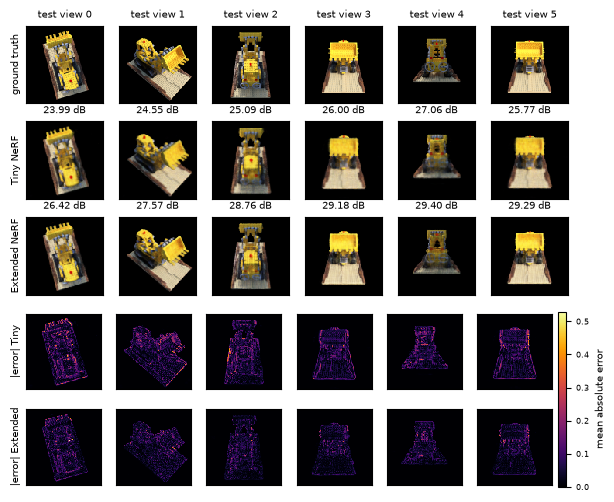

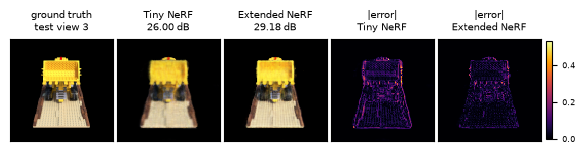

report view: 3 | Extended - Tiny gain per view (dB): [2.43, 3.02, 3.67, 3.19, 2.35, 3.52]


In [16]:
# All six held-out views: ground truth, both models and their absolute error maps.
abs_error = {name: [(renders[name][i] - test_images[i]).abs().mean(-1).cpu().numpy() for i in range(6)]
             for name in ("Tiny NeRF", "Extended NeRF")}
vmax = max(error_map.max() for name in abs_error for error_map in abs_error[name])   # one colour scale
rows = [("ground truth", [image.cpu().numpy() for image in test_images], False),
        ("Tiny NeRF", [image.cpu().numpy() for image in renders["Tiny NeRF"]], False),
        ("Extended NeRF", [image.cpu().numpy() for image in renders["Extended NeRF"]], False),
        ("|error| Tiny", abs_error["Tiny NeRF"], True), ("|error| Extended", abs_error["Extended NeRF"], True)]
fig, axes = plt.subplots(5, 6, figsize=(TEXT_WIDTH, 6.0))
for row, (label, imgs, is_error) in enumerate(rows):
    for col in range(6):
        ax = axes[row, col]
        if is_error:
            error_image = ax.imshow(imgs[col], cmap="inferno", vmin=0, vmax=vmax, interpolation="nearest")
        else:
            ax.imshow(imgs[col], interpolation="nearest")
        if label in results:
            ax.set_title(f"{results[label]['psnr'][col]:.2f} dB")
        elif row == 0:
            ax.set_title(f"test view {col}")
        ax.set_xticks([]); ax.set_yticks([])
    axes[row, 0].set_ylabel(label)
fig.colorbar(error_image, ax=axes[3:, :], fraction=0.02, pad=0.01, label="mean absolute error")
plt.show()

# Report figure 1: the view ranked in the middle by Extended NeRF's gain over Tiny NeRF, as
# ground truth | Tiny NeRF | Extended NeRF | both error maps on the shared colour scale above.
gains = np.array(results["Extended NeRF"]["psnr"]) - np.array(results["Tiny NeRF"]["psnr"])
report_view = int(np.argsort(gains)[len(gains) // 2])
fig, axes = plt.subplots(1, 5, figsize=(TEXT_WIDTH, 1.75), gridspec_kw={"wspace": 0.04})
panels = [(test_images[report_view].cpu().numpy(), f"ground truth\ntest view {report_view}", None),
          (renders["Tiny NeRF"][report_view].cpu().numpy(),
           f"Tiny NeRF\n{results['Tiny NeRF']['psnr'][report_view]:.2f} dB", None),
          (renders["Extended NeRF"][report_view].cpu().numpy(),
           f"Extended NeRF\n{results['Extended NeRF']['psnr'][report_view]:.2f} dB", None),
          (abs_error["Tiny NeRF"][report_view], "|error|\nTiny NeRF", "inferno"),
          (abs_error["Extended NeRF"][report_view], "|error|\nExtended NeRF", "inferno")]
for ax, (img, title, cmap) in zip(axes, panels):
    if cmap is None:
        ax.imshow(img, interpolation="nearest")
    else:
        error_image = ax.imshow(img, cmap=cmap, vmin=0, vmax=vmax, interpolation="nearest")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(error_image, ax=axes, fraction=0.012, pad=0.01, aspect=15)
plt.savefig("figure_1_test_views.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("report view:", report_view, "| Extended - Tiny gain per view (dB):", np.round(gains, 2).tolist())

## 3. Training curves (all four models, identical training budget)
Test PSNR after every epoch, from the histories saved by the training notebooks. The curves show
whether each model had converged by the last epoch; the weights used everywhere else are the
last epoch's.

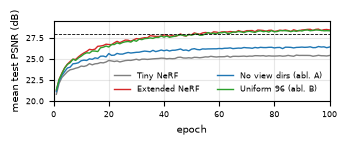

curves | Tiny NeRF | epochs 100 | best 25.45 dB | final 25.41 dB | last-10-epoch gain +0.01 dB | 13.3 s per epoch | 22.2 min
curves | Extended NeRF | epochs 100 | best 28.54 dB | final 28.44 dB | last-10-epoch gain +0.09 dB | 49.1 s per epoch | 81.8 min
curves | No view dirs (abl. A) | epochs 100 | best 26.47 dB | final 26.41 dB | last-10-epoch gain +0.04 dB | 34.5 s per epoch | 57.5 min
curves | Uniform 96 (abl. B) | epochs 100 | best 28.44 dB | final 28.34 dB | last-10-epoch gain +0.07 dB | 25.7 s per epoch | 42.9 min


In [17]:
# Test PSNR during training for the four models, from the saved histories.
histories = json.load(open("training_history.json"))
HISTORY_KEYS = {"Tiny NeRF": "TinyNeRF", "Extended NeRF": "ExtendedNeRF",
                "No view dirs (abl. A)": "Ablation_NoViewDirs", "Uniform 96 (abl. B)": "Ablation_Uniform96"}
colors = {"Tiny NeRF": "tab:gray", "Extended NeRF": "tab:red",
          "No view dirs (abl. A)": "tab:blue", "Uniform 96 (abl. B)": "tab:green"}

fig, ax = plt.subplots(figsize=(COLUMN_WIDTH, 1.35))
for name in MODEL_NAMES:
    history = histories[HISTORY_KEYS[name]]
    ax.plot(np.arange(1, len(history["test_psnr"]) + 1), history["test_psnr"], color=colors[name], lw=1,
            label=name)
ax.axhline(28, ls="--", c="k", lw=0.6)
ax.set_xlabel("epoch"); ax.set_ylabel("mean test PSNR (dB)")
ax.set_ylim(20, 29.5); ax.set_xlim(0, len(history["test_psnr"])); ax.grid(alpha=0.3)
ax.legend(ncol=2, loc="lower right", frameon=False)
plt.tight_layout()
plt.savefig("figure_3_curves.pdf", bbox_inches="tight")
plt.show()

for name in MODEL_NAMES:
    history = histories[HISTORY_KEYS[name]]
    last10 = np.mean(history["test_psnr"][-10:]) - np.mean(history["test_psnr"][-20:-10])
    print(f"curves | {name} | epochs {len(history['test_psnr'])} | best {max(history['test_psnr']):.2f} dB | "
          f"final {history['test_psnr'][-1]:.2f} dB | last-10-epoch gain {last10:+.2f} dB | "
          f"{np.mean(history['epoch_seconds']):.1f} s per epoch | "
          f"{np.sum(history['epoch_seconds']) / 60:.1f} min")

## 4. View-dependent appearance
Two questions. **Does Extended NeRF use the direction?** Freezing its direction input at one fixed
direction (test view 3's) while keeping the geometry must change the render if it does, while the
matte ablation A cannot change at all. **Is the change real?** Take points on the object's surface
seen in test view 0, find every training camera that sees the same point unoccluded, and read the
point's brightness in those photographs. If the photographs change with the camera, the scene is
view-dependent, and a model's renders of those same rays should follow the change.

In [18]:
# (1) Re-render test view 0 with every ray's direction input frozen to test view 3's direction.
def render_frozen_direction(coarse, fine, c2w, frozen_dir, chunk=4096):
    """Hierarchical render in which the colour head always receives frozen_dir."""
    class Frozen(torch.nn.Module):
        """Wraps a network so that its colour head sees frozen_dir instead of the ray's direction."""
        def __init__(self, net):
            super().__init__(); self.net = net
        def forward(self, x, d):
            return self.net(x, frozen_dir.expand_as(d))
    return render_image(lambda o, d: render_rays(Frozen(coarse), Frozen(fine), o, d,
                                                 NEAR, FAR, N_C, N_F)[1], c2w, chunk).clamp(0, 1)

view = 0
frozen_dir = F.normalize(-test_poses[3][:3, 2], dim=0)      # test view 3 looks along its -z axis
frozen = {"Extended NeRF": render_frozen_direction(ext_coarse, ext_fine, test_poses[view], frozen_dir),
          "No view dirs (abl. A)": render_frozen_direction(noview_coarse, noview_fine, test_poses[view],
                                                           frozen_dir)}
change = {name: (frozen[name] - renders[name][view]).abs().mean(-1) for name in frozen}
frozen_psnr = {name: psnr(frozen[name], test_images[view]) for name in frozen}
for name in frozen:
    print(f"frozen direction | {name} | mean colour change {change[name].mean().item():.4f} | "
          f"PSNR {frozen_psnr[name]:.2f} dB with the direction frozen vs {results[name]['psnr'][view]:.2f} dB")

frozen direction | Extended NeRF | mean colour change 0.0277 | PSNR 21.38 dB with the direction frozen vs 26.42 dB
frozen direction | No view dirs (abl. A) | mean colour change 0.0000 | PSNR 24.47 dB with the direction frozen vs 24.47 dB


Now the photographs: project points on the object that lie away from image edges (and off the black background, which the models also render as opaque) into every training camera, and compare brightness across cameras.

In [19]:
# (2) Do the photographs themselves change with viewpoint, and do the renders follow them?
def render_with_depth(coarse, fine, rays_o, rays_d, chunk=4096):
    """Final colour, expected depth sum(w t) and opacity sum(w) of the hierarchical renderer."""
    parts = []
    with torch.no_grad():
        for i in range(0, rays_o.shape[0], chunk):
            _, rgb, extras = render_rays(coarse, fine, rays_o[i:i + chunk], rays_d[i:i + chunk],
                                         NEAR, FAR, N_C, N_F, return_extras=True)
            parts.append((rgb.clamp(0, 1), (extras["weights_fine"] * extras["t_all"]).sum(-1),
                          extras["weights_fine"].sum(-1)))
    return [torch.cat(column, 0) for column in zip(*parts)]


def edge_strength(img):
    """Mean absolute difference between an image and its 3 x 3 local mean: large at edges."""
    img_chw = img.permute(2, 0, 1)[None]
    local_mean = F.avg_pool2d(img_chw, 3, stride=1, padding=1, count_include_pad=False)
    return (img_chw - local_mean).abs().mean(1)[0]                            # [H, W]


def read_pixels(img_chw, i, j):
    """Bilinear read of an image at fractional pixel coordinates (i = column, j = row)."""
    grid = torch.stack([i / (W - 1) * 2 - 1, j / (H - 1) * 2 - 1], -1)[None, None]
    return F.grid_sample(img_chw[None], grid, align_corners=True)[0, :, 0].T  # [N, channels]


LUMA = torch.tensor([0.299, 0.587, 0.114], device=device)    # brightness of an RGB colour
FLAT, DEPTH_TOL, MIN_CAMERAS = 0.02, 0.05, 10

# Surface points: pixels of test view 0 on the object (the background is black, and the models
# render it as opaque black too, so opacity alone would admit it), away from edges, placed at the
# rendered depth.
rays_o0, rays_d0 = (rays.reshape(-1, 3) for rays in get_rays(K, test_poses[view], H, W))
_, depth0, opacity0 = render_with_depth(ext_coarse, ext_fine, rays_o0, rays_d0)
flat0 = edge_strength(test_images[view]).reshape(-1) < FLAT
on_object = test_images[view].reshape(-1, 3).sum(-1) > 0.05          # not the black background
candidates = torch.nonzero((opacity0 > 0.99) & flat0 & on_object).squeeze(1)
chosen = candidates[torch.linspace(0, len(candidates) - 1, min(400, len(candidates)), device=device).long()]
points = rays_o0[chosen] + depth0[chosen, None] * rays_d0[chosen]

# Every training camera: project the points (get_rays in reverse), render the rays through those
# pixels, and keep a point only where the camera sees it unoccluded and away from an edge.
photo, ext_lum, abl_lum = [], [], []
for c2w, img in zip(train_poses, train_images):
    rotation, origin = c2w[:3, :3], c2w[:3, 3]
    p_cam = (points - origin) @ rotation                  # camera coordinates R^T (p - o)
    depth = (-p_cam[:, 2]).clamp_min(1e-3)                # depth along the viewing axis
    px_col = K[0, 2] + K[0, 0] * p_cam[:, 0] / depth      # pixel coordinates of each point
    px_row = K[1, 2] - K[1, 1] * p_cam[:, 1] / depth
    in_frame = ((-p_cam[:, 2] > NEAR) & (px_col >= 1) & (px_col <= W - 2)
                & (px_row >= 1) & (px_row <= H - 2))
    px_col, px_row = torch.where(in_frame, px_col, K[0, 2]), torch.where(in_frame, px_row, K[1, 2])
    rays_d = torch.stack([(px_col - K[0, 2]) / K[0, 0], -(px_row - K[1, 2]) / K[1, 1],
                          -torch.ones_like(px_col)], -1) @ rotation.T
    rays_o = origin.expand_as(rays_d)
    ext_rgb, ext_depth, ext_opacity = render_with_depth(ext_coarse, ext_fine, rays_o, rays_d)
    abl_rgb, _, _ = render_with_depth(noview_coarse, noview_fine, rays_o, rays_d)
    seen = (in_frame & (ext_opacity > 0.99) & ((ext_depth - depth).abs() < DEPTH_TOL)
            & (read_pixels(edge_strength(img)[None], px_col, px_row)[:, 0] < FLAT))
    missing = torch.full_like(depth, float("nan"))
    photo.append(torch.where(seen, read_pixels(img.permute(2, 0, 1), px_col, px_row) @ LUMA, missing))
    ext_lum.append(torch.where(seen, ext_rgb @ LUMA, missing))
    abl_lum.append(torch.where(seen, abl_rgb @ LUMA, missing))
photo, ext_lum, abl_lum = (torch.stack(per_camera, 1).cpu().numpy()
                           for per_camera in (photo, ext_lum, abl_lum))

n_cameras = (~np.isnan(photo)).sum(1)
keep = n_cameras >= MIN_CAMERAS


def per_point(stat_fn, *arrays):
    """Apply stat_fn to the cameras that see each kept point."""
    out = []
    for point_rows in zip(*(array[keep] for array in arrays)):
        seen_by = ~np.isnan(point_rows[0])
        out.append(stat_fn(*(values[seen_by] for values in point_rows)))
    return np.array(out)


def correlation(a, b):
    """Pearson correlation across cameras; undefined (nan) when either side does not vary."""
    a, b = a - a.mean(), b - b.mean()
    scale = np.sqrt((a ** 2).sum() * (b ** 2).sum())
    return float((a * b).sum() / scale) if scale > 1e-12 else float("nan")


spread = {name: per_point(np.std, values)
          for name, values in (("photographs", photo), ("Extended NeRF", ext_lum),
                               ("No view dirs (abl. A)", abl_lum))}
rms = {name: per_point(lambda photo_values, render_values:
                       np.sqrt(np.mean((render_values - photo_values) ** 2)), photo, values)
       for name, values in (("Extended NeRF", ext_lum), ("No view dirs (abl. A)", abl_lum))}
corr = {name: per_point(correlation, photo, values)
        for name, values in (("Extended NeRF", ext_lum), ("No view dirs (abl. A)", abl_lum))}
print(f"photo consistency | {int(keep.sum())} surface points seen by at least {MIN_CAMERAS} training "
      f"cameras | median {int(np.median(n_cameras[keep]))} cameras per point")
for stat, stat_fn in (("median", np.median), ("mean", np.mean)):
    print(f"photo consistency | brightness spread across cameras ({stat} std) | photographs "
          f"{stat_fn(spread['photographs']):.4f} | Extended NeRF {stat_fn(spread['Extended NeRF']):.4f} | "
          f"ablation A {stat_fn(spread['No view dirs (abl. A)']):.4f}")
for name in rms:
    print(f"photo consistency | {name} | RMS brightness error against the photographs {rms[name].mean():.4f} | "
          f"median correlation with the photographs across cameras {np.nanmedian(corr[name]):.2f}")
# Share of points where a model's renders vary more across cameras than the photographs do.
over = {name: float(np.mean(spread[name] > spread["photographs"])) for name in rms}
print(f"photo consistency | renders vary more than the photographs at | Extended NeRF "
      f"{100 * over['Extended NeRF']:.0f}% of points | ablation A {100 * over['No view dirs (abl. A)']:.0f}% of points")

photo consistency | 162 surface points seen by at least 10 training cameras | median 18 cameras per point
photo consistency | brightness spread across cameras (median std) | photographs 0.0199 | Extended NeRF 0.0272 | ablation A 0.0167
photo consistency | brightness spread across cameras (mean std) | photographs 0.0281 | Extended NeRF 0.0328 | ablation A 0.0211
photo consistency | Extended NeRF | RMS brightness error against the photographs 0.0255 | median correlation with the photographs across cameras 0.69
photo consistency | No view dirs (abl. A) | RMS brightness error against the photographs 0.0285 | median correlation with the photographs across cameras 0.40
photo consistency | renders vary more than the photographs at | Extended NeRF 75% of points | ablation A 30% of points


The surface points above leave out the edges. Next, where in the image the direction input lowers the error: edge pixels against flat pixels, over all six test views.

In [20]:
# (3) Where in the image does the direction input lower the error? Split every test pixel into
# edge pixels (edge strength at or above FLAT) and flat pixels, then share out the squared error.
edge_px, sq_err_abl_a, sq_err_ext = [], [], []
for i in range(len(test_images)):
    edge_px.append((edge_strength(test_images[i]) >= FLAT).reshape(-1))
    sq_err_abl_a.append(((renders["No view dirs (abl. A)"][i] - test_images[i]) ** 2)
                        .mean(-1).reshape(-1))
    sq_err_ext.append(((renders["Extended NeRF"][i] - test_images[i]) ** 2).mean(-1).reshape(-1))
edge_px, sq_err_abl_a, sq_err_ext = (torch.cat(per_view)
                                     for per_view in (edge_px, sq_err_abl_a, sq_err_ext))
reduction = sq_err_abl_a - sq_err_ext              # positive where Extended NeRF is closer
print(f"error split | edge pixels {100 * edge_px.float().mean().item():.1f}% of test pixels | "
      f"{100 * (sq_err_abl_a[edge_px].sum() / sq_err_abl_a.sum()).item():.1f}% of ablation A's squared error | "
      f"{100 * (reduction[edge_px].sum() / reduction.sum()).item():.1f}% of the reduction to Extended NeRF")

error split | edge pixels 25.5% of test pixels | 90.4% of ablation A's squared error | 89.2% of the reduction to Extended NeRF


The report's figure: the frozen-direction maps, then every kept surface point's brightness spread and its correlation with the photographs, for both models.

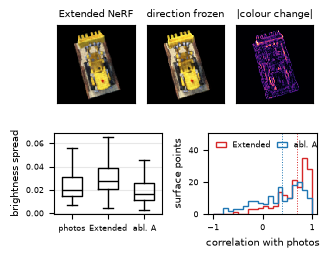

In [21]:
# Report figure 4: the frozen-direction experiment (top) and every kept surface point (bottom).
# All kept points are shown rather than a chosen one: left, how much a point's brightness varies
# across the cameras that see it; right, how closely each model's brightness follows the
# photographs from camera to camera.
fig = plt.figure(figsize=(COLUMN_WIDTH, 2.45))
outer = fig.add_gridspec(2, 1, height_ratios=[1, 1.05], hspace=0.38)
top = outer[0].subgridspec(1, 3, wspace=0.05)
bottom = outer[1].subgridspec(1, 2, wspace=0.42)
panels = [(renders["Extended NeRF"][view].cpu().numpy(), "Extended NeRF"),
          (frozen["Extended NeRF"].cpu().numpy(), "direction frozen"),
          (change["Extended NeRF"].cpu().numpy(), "|colour change|")]
for col, (img, title) in enumerate(panels):
    ax = fig.add_subplot(top[0, col])
    ax.imshow(img, cmap="magma" if img.ndim == 2 else None, interpolation="nearest")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

ax = fig.add_subplot(bottom[0, 0])
ax.boxplot([spread["photographs"], spread["Extended NeRF"], spread["No view dirs (abl. A)"]],
           showfliers=False, widths=0.55, medianprops={"color": "k"})
ax.set_xticks([1, 2, 3], ["photos", "Extended", "abl. A"])
ax.set_ylabel("brightness spread"); ax.grid(alpha=0.3, axis="y")

ax = fig.add_subplot(bottom[0, 1])
bins = np.linspace(-1, 1, 21)
peak = 0
for name, colour, label in (("Extended NeRF", "tab:red", "Extended"),
                            ("No view dirs (abl. A)", "tab:blue", "abl. A")):
    counts, _, _ = ax.hist(corr[name][~np.isnan(corr[name])], bins=bins, histtype="step", color=colour,
                           lw=1, label=label)
    ax.axvline(np.nanmedian(corr[name]), color=colour, lw=0.7, ls=":")
    peak = max(peak, counts.max())
ax.set_ylim(0, 1.45 * peak)                        # headroom for the legend
ax.set_xlabel("correlation with photos"); ax.set_ylabel("surface points")
ax.legend(loc="upper left", frameon=False, handlelength=1.2, ncol=2, columnspacing=0.8)
plt.savefig("figure_4_view_dependence.pdf", bbox_inches="tight", dpi=300)
plt.show()

## 5. Hierarchical sampling: where the samples go, and when it pays
First, for every ray of test view 0 that hits the object: the share of each sampler's points that
land near the surface, taken as the depth interval holding the central 90% of the final weights
(widened by half its width on each side, and at least one uniform bin wide). Then the sample
budget: a trained NeRF is a continuous function of position, so it can be rendered with more or
fewer samples per ray than it was trained with. Extended NeRF keeps its 1:2 split between coarse
and fine samples; ablation B uses evenly spaced samples. Comparing them at the same number of
**network evaluations per ray** (coarse plus fine for the hierarchical model) compares equal work.

In [22]:
# Hierarchical sampling: where do the samples land? For every ray of test view 0 we compare the
# share of samples that fall inside the interval holding the central 90% of the final weights
# (i.e. close to the surface), for uniform sampling vs the coarse-to-fine scheme.
view = 0
rays_o, rays_d = get_rays(K, test_poses[view], H, W)
rays_o, rays_d = rays_o.reshape(-1, 3), rays_d.reshape(-1, 3)
with torch.no_grad():
    extras = [render_rays(ext_coarse, ext_fine, rays_o[i:i + 4096], rays_d[i:i + 4096], NEAR, FAR, N_C, N_F,
                      return_extras=True)[2] for i in range(0, rays_o.shape[0], 4096)]
extras = {key: torch.cat([chunk_extras[key] for chunk_extras in extras], 0) for key in extras[0]}
hit = test_images[view].reshape(-1, 3).sum(-1) > 0.05          # rays that hit the object (non-black pixels)

def surface_interval(t_vals, weights, lower=0.05, upper=0.95):
    """Per ray, the depths at which the cumulative weight reaches lower and upper."""
    cdf = torch.cumsum(weights, -1) / weights.sum(-1, keepdim=True).clamp_min(1e-8)
    t_lo = torch.gather(t_vals, -1, torch.searchsorted(cdf, torch.full_like(cdf[:, :1], lower)).clamp(max=t_vals.shape[-1] - 1))
    t_hi = torch.gather(t_vals, -1, torch.searchsorted(cdf, torch.full_like(cdf[:, :1], upper)).clamp(max=t_vals.shape[-1] - 1))
    return t_lo, t_hi

t_lo, t_hi = surface_interval(extras["t_all"], extras["weights_fine"])
width = (t_hi - t_lo).clamp_min((FAR - NEAR) / (N_C + N_F))     # at least one uniform bin wide
inside = lambda t_vals: ((t_vals >= t_lo - 0.5 * width) & (t_vals <= t_hi + 0.5 * width)).float().mean(-1)
t_uniform96 = stratified_t_vals(rays_o, NEAR, FAR, N_C + N_F)
share = {"uniform, 96 samples": inside(t_uniform96)[hit].mean().item(),
         "coarse, 32 samples": inside(extras["t_coarse"])[hit].mean().item(),
         "fine, 64 importance samples": inside(extras["t_fine"])[hit].mean().item(),
         "hierarchical, all 96": inside(extras["t_all"])[hit].mean().item()}
for key, fraction in share.items():
    print(f"share of samples near the surface ({key:28s}): {100 * fraction:5.1f}%  [{hit.sum().item():,} object rays]")

share of samples near the surface (uniform, 96 samples         ):  14.3%  [3,371 object rays]
share of samples near the surface (coarse, 32 samples          ):  14.0%  [3,371 object rays]
share of samples near the surface (fine, 64 importance samples ):  84.7%  [3,371 object rays]
share of samples near the surface (hierarchical, all 96        ):  61.1%  [3,371 object rays]


The sample budget: Extended NeRF and ablation B rendered at several numbers of samples per ray.

In [23]:
# Sample budget at render time: mean test PSNR against the number of network evaluations per ray.
def mean_test_psnr(render_fn):
    """Mean PSNR over the six test views of one renderer (rays -> colour)."""
    # 1,024 rays per chunk: at 256 samples per ray a 4,096-ray chunk needs 512 MB per layer,
    # more than a 4 GB GPU slice has free at that point.
    return float(np.mean([psnr(render_image(render_fn, test_poses[i], chunk=1024).clamp(0, 1),
                               test_images[i]) for i in range(len(test_images))]))

BUDGETS = [24, 48, 96, 192]                        # samples the final network sees per ray
sweep = {"hierarchical": {}, "uniform": {}}        # keyed by network evaluations per ray
for budget in BUDGETS:
    n_coarse = budget // 3                         # the trained 1:2 split of coarse to fine samples
    render_fn = lambda o, d, n_c=n_coarse, n_f=budget - n_coarse: render_rays(
        ext_coarse, ext_fine, o, d, NEAR, FAR, n_c, n_f)[1]
    sweep["hierarchical"][n_coarse + budget] = mean_test_psnr(render_fn)
    print(f"budget | hierarchical | coarse {n_coarse} + fine {budget - n_coarse} | "
          f"{n_coarse + budget} evaluations | PSNR {sweep['hierarchical'][n_coarse + budget]:.2f} dB")
for evaluations in sorted(set(BUDGETS) | set(sweep["hierarchical"])):
    sweep["uniform"][evaluations] = mean_test_psnr(
        lambda o, d, n=evaluations: render_rays_uniform(uniform_net, o, d, NEAR, FAR, n))
    print(f"budget | uniform | {evaluations} samples | {evaluations} evaluations | "
          f"PSNR {sweep['uniform'][evaluations]:.2f} dB")
for evaluations, hier_psnr in sweep["hierarchical"].items():
    uniform_psnr = sweep["uniform"][evaluations]
    print(f"equal work | {evaluations} evaluations per ray | hierarchical {hier_psnr:.2f} dB | uniform "
          f"{uniform_psnr:.2f} dB | difference {hier_psnr - uniform_psnr:+.2f} dB")

budget | hierarchical | coarse 8 + fine 16 | 32 evaluations | PSNR 21.56 dB


budget | hierarchical | coarse 16 + fine 32 | 64 evaluations | PSNR 26.62 dB


budget | hierarchical | coarse 32 + fine 64 | 128 evaluations | PSNR 28.44 dB


budget | hierarchical | coarse 64 + fine 128 | 256 evaluations | PSNR 28.58 dB
budget | uniform | 24 samples | 24 evaluations | PSNR 22.62 dB


budget | uniform | 32 samples | 32 evaluations | PSNR 24.17 dB


...

budget | uniform | 64 samples | 64 evaluations | PSNR 27.86 dB


budget | uniform | 96 samples | 96 evaluations | PSNR 28.34 dB


budget | uniform | 128 samples | 128 evaluations | PSNR 28.39 dB


budget | uniform | 192 samples | 192 evaluations | PSNR 28.42 dB


budget | uniform | 256 samples | 256 evaluations | PSNR 28.42 dB
equal work | 32 evaluations per ray | hierarchical 21.56 dB | uniform 24.17 dB | difference -2.61 dB
equal work | 64 evaluations per ray | hierarchical 26.62 dB | uniform 27.86 dB | difference -1.25 dB
equal work | 128 evaluations per ray | hierarchical 28.44 dB | uniform 28.39 dB | difference +0.05 dB
equal work | 256 evaluations per ray | hierarchical 28.58 dB | uniform 28.42 dB | difference +0.16 dB


The report's figure. Top: on one object ray, the coarse weights and where each sampler's samples land (the evenly spaced coarse samples, and the fine samples drawn from the coarse weights). Bottom: the sample budget against equal work.

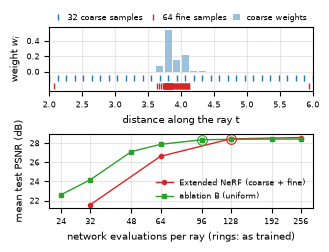

In [24]:
# Report figure 5, top: one object ray of test view 0 (the middle one in pixel order). The bars are
# the coarse network's weights; below them, one row of ticks per sample set, so the evenly spaced
# coarse samples can be compared with the fine samples that sample_pdf drew from those weights.
object_rays = torch.nonzero(hit).squeeze(1)
ray = int(object_rays[len(object_rays) // 2])
t_coarse = extras["t_coarse"][ray].cpu().numpy()
w_coarse = extras["weights_coarse"][ray].cpu().numpy()
t_fine = extras["t_fine"][ray].cpu().numpy()
peak = float(w_coarse.max())

fig, axes = plt.subplots(2, 1, figsize=(COLUMN_WIDTH, 2.35),
                         gridspec_kw={"height_ratios": [1, 1.15], "hspace": 0.62})
ax = axes[0]
ax.bar(t_coarse, w_coarse, width=(FAR - NEAR) / N_C * 0.9, color="tab:blue", alpha=0.45,
       label="coarse weights")
ax.plot(t_coarse, np.full(N_C, -0.15 * peak), "|", color="tab:blue", ms=4,
        label=f"{N_C} coarse samples")
ax.plot(t_fine, np.full(N_F, -0.36 * peak), "|", color="tab:red", ms=4,
        label=f"{N_F} fine samples")
ax.set_xlim(NEAR, FAR); ax.set_ylim(-0.48 * peak, 1.08 * peak)
ax.set_yticks([tick for tick in plt.MaxNLocator(3).tick_values(0, peak) if 0 <= tick <= 1.05 * peak])
ax.set_xlabel("distance along the ray t"); ax.set_ylabel("weight $w_i$")
ax.grid(alpha=0.3)
# The legend sits in its own row above the panel, where it cannot cover any data.
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncol=3, frameon=False, handlelength=0.8,
          columnspacing=0.8, borderaxespad=0.2)

# Bottom: mean test PSNR against network evaluations per ray, for both samplers.
ax = axes[1]
for name, colour, style in (("hierarchical", "tab:red", "-o"), ("uniform", "tab:green", "-s")):
    evaluations = sorted(sweep[name])
    label = "Extended NeRF (coarse + fine)" if name == "hierarchical" else "ablation B (uniform)"
    ax.plot(evaluations, [sweep[name][n] for n in evaluations], style, ms=3, lw=1, color=colour,
            label=label)
# A ring marks the budget each model was trained at (no full-height guide line to cross the legend).
for name, colour, trained in (("hierarchical", "tab:red", N_C + N_C + N_F),
                              ("uniform", "tab:green", N_C + N_F)):
    ax.plot(trained, sweep[name][trained], "o", ms=7, mfc="none", mec=colour, mew=0.8)
ax.set_xscale("log", base=2)
ax.set_xticks(sorted(sweep["uniform"])); ax.set_xticklabels([str(n) for n in sorted(sweep["uniform"])])
ax.set_xlabel("network evaluations per ray (rings: as trained)"); ax.set_ylabel("mean test PSNR (dB)")
ax.legend(loc="lower right", frameon=False); ax.grid(alpha=0.3)
plt.savefig("figure_5_sampling.pdf", bbox_inches="tight")
plt.show()

## 6. Novel-view synthesis: a 360-degree turntable (the "3D movie")
The camera circles the object 30 degrees above the horizontal at radius 4 (the tutorial's
`pose_spherical(theta, -30, 4)`). These 40 poses are generated, not taken from the dataset, so
every frame is a novel view. The strip below is the report's figure; `nerf_turntable.gif` is the
full 40-frame movie, Tiny NeRF on the left and Extended NeRF on the right.

turntable | 40 frames | camera 30 degrees above the horizontal | radius 4


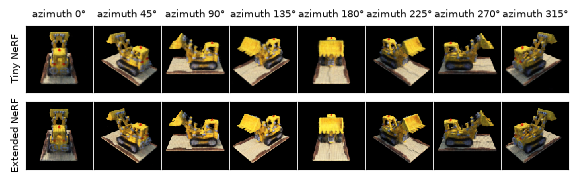

saved figure_2_novel_views.pdf and nerf_turntable.gif (40 frames, Tiny NeRF | Extended NeRF)


In [25]:
# Novel views: a turntable of 40 frames, 9 degrees apart, rendered by both models.
thetas = np.linspace(0, 360, 40, endpoint=False)
frames = {name: [render_image(RENDERERS[name], pose_spherical(theta, -30., 4.)).clamp(0, 1).cpu().numpy()
                 for theta in thetas] for name in ("Tiny NeRF", "Extended NeRF")}
print(f"turntable | {len(thetas)} frames | camera 30 degrees above the horizontal | radius 4")

strip_idx = np.arange(0, 40, 5)                    # 8 frames, 45 degrees apart
fig, axes = plt.subplots(2, len(strip_idx), figsize=(TEXT_WIDTH, 1.95),
                         gridspec_kw={"wspace": 0.03, "hspace": 0.05})
for row, name in enumerate(("Tiny NeRF", "Extended NeRF")):
    for col, frame in enumerate(strip_idx):
        axes[row, col].imshow(frames[name][frame], interpolation="nearest")
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
        if row == 0:
            axes[row, col].set_title(f"azimuth {thetas[frame]:.0f}°")
    axes[row, 0].set_ylabel(name)
plt.savefig("figure_2_novel_views.pdf", bbox_inches="tight", dpi=300)
plt.show()

# Side-by-side GIF: Tiny NeRF (left) | Extended NeRF (right)
gif_frames = [Image.fromarray((np.concatenate([tiny_frame, ext_frame], axis=1) * 255).astype(np.uint8))
              .resize((400, 200), Image.NEAREST)
              for tiny_frame, ext_frame in zip(frames["Tiny NeRF"], frames["Extended NeRF"])]
gif_frames[0].save("nerf_turntable.gif", save_all=True, append_images=gif_frames[1:], duration=100, loop=0)
print("saved figure_2_novel_views.pdf and nerf_turntable.gif (40 frames, Tiny NeRF | Extended NeRF)")

## 7. Summary of all reported numbers
One line per model with every number in the report's table, then the saved summary file.

In [26]:
# Every number quoted in the report: one summary line per model, and results_summary.json.
EVALUATIONS = {"Tiny NeRF": N_SAMPLES_TINY, "Extended NeRF": N_C + N_C + N_F,
               "No view dirs (abl. A)": N_C + N_C + N_F, "Uniform 96 (abl. B)": N_C + N_F}
summary = {}
for name in MODEL_NAMES:
    result, history = results[name], histories[HISTORY_KEYS[name]]
    summary[name] = {"mean_psnr": float(np.mean(result["psnr"])), "std_psnr": float(np.std(result["psnr"])),
                     "mean_ssim": float(np.mean(result["ssim"])), "psnr_per_view": result["psnr"],
                     "ssim_per_view": result["ssim"], "ms_per_image": 1000 * result["render_seconds"],
                     "params": result["params"], "evaluations_per_ray": EVALUATIONS[name],
                     "train_minutes": float(np.sum(history["epoch_seconds"]) / 60),
                     "seconds_per_epoch": float(np.mean(history["epoch_seconds"]))}
    if "coarse_psnr" in result:
        summary[name]["coarse_mean_psnr"] = float(np.mean(result["coarse_psnr"]))
    line = summary[name]
    coarse = f"{line['coarse_mean_psnr']:.2f}" if "coarse_mean_psnr" in line else "none"
    print(f"summary | {name} | PSNR {line['mean_psnr']:.2f} | sd {line['std_psnr']:.2f} | "
          f"SSIM {line['mean_ssim']:.3f} | coarse PSNR {coarse} | {line['evaluations_per_ray']} evaluations "
          f"per ray | {line['ms_per_image']:.0f} ms per image | {line['params']:,} parameters | "
          f"{line['train_minutes']:.1f} min training | {line['seconds_per_epoch']:.1f} s per epoch")
summary["paired"] = {f"{model} - {baseline}": diff.tolist() for (model, baseline), diff in paired.items()}
summary["frozen_direction"] = {"mean_change": {name: change[name].mean().item() for name in change},
                               "psnr": frozen_psnr}
summary["photo_consistency"] = {
    "points": int(keep.sum()),
    "mean_spread": {name: float(values.mean()) for name, values in spread.items()},
    "median_spread": {name: float(np.median(values)) for name, values in spread.items()},
    "share_varying_more_than_photographs": over,
    "rms": {name: float(values.mean()) for name, values in rms.items()},
    "median_correlation": {name: float(np.nanmedian(values)) for name, values in corr.items()}}
summary["error_split"] = {"edge_pixel_share": edge_px.float().mean().item(),
                          "edge_share_of_ablation_a_error": (sq_err_abl_a[edge_px].sum()
                                                             / sq_err_abl_a.sum()).item(),
                          "edge_share_of_reduction": (reduction[edge_px].sum() / reduction.sum()).item()}
summary["share_near_surface"] = share
summary["sample_budget"] = sweep
summary["device"] = gpu_name
json.dump(summary, open("results_summary.json", "w"), indent=1)
print("saved results_summary.json")

summary | Tiny NeRF | PSNR 25.41 | sd 1.00 | SSIM 0.894 | coarse PSNR none | 64 evaluations per ray | 33 ms per image | 22,148 parameters | 22.2 min training | 13.3 s per epoch
summary | Extended NeRF | PSNR 28.44 | sd 1.09 | SSIM 0.940 | coarse PSNR 25.95 | 128 evaluations per ray | 142 ms per image | 96,904 parameters | 81.8 min training | 49.1 s per epoch
summary | No view dirs (abl. A) | PSNR 26.41 | sd 1.14 | SSIM 0.917 | coarse PSNR 24.33 | 128 evaluations per ray | 137 ms per image | 96,904 parameters | 57.5 min training | 34.5 s per epoch
summary | Uniform 96 (abl. B) | PSNR 28.34 | sd 1.27 | SSIM 0.937 | coarse PSNR none | 96 evaluations per ray | 101 ms per image | 48,452 parameters | 42.9 min training | 25.7 s per epoch
saved results_summary.json
